In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
sns.set_theme(style="whitegrid", palette="muted")

In [5]:
df = pd.read_csv('dataset.csv')
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


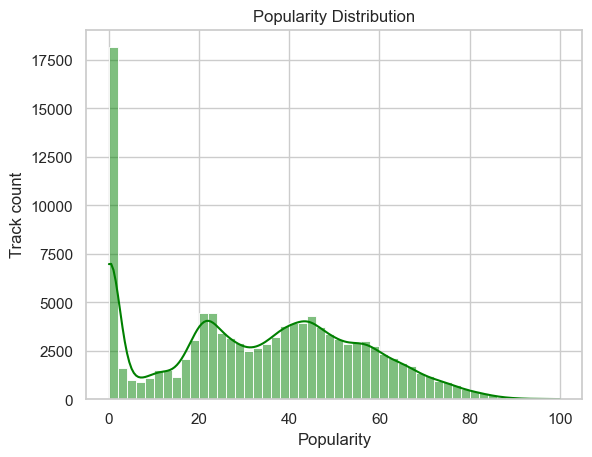

In [6]:
sns.histplot(data=df, x='popularity', bins=50, kde=True, color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Track count')
plt.show()


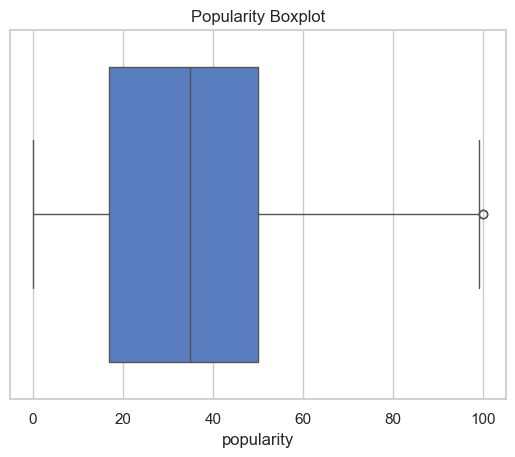

In [7]:
sns.boxplot(data=df, x='popularity')
plt.title('Popularity Boxplot')
plt.show()

In [8]:
top_genres = (
    df.groupby('track_genre')
    .popularity.mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

top_genres

Index(['pop-film', 'k-pop', 'chill', 'sad', 'grunge', 'indian', 'anime', 'emo',
       'sertanejo', 'pop'],
      dtype='str', name='track_genre')

In [9]:
lowest_popularity_genres = (
    df.groupby('track_genre')
    .popularity.mean()
    .sort_values()
    .head(10)
    .index
)

lowest_popularity_genres

Index(['iranian', 'romance', 'latin', 'detroit-techno', 'chicago-house',
       'classical', 'jazz', 'grindcore', 'kids', 'idm'],
      dtype='str', name='track_genre')

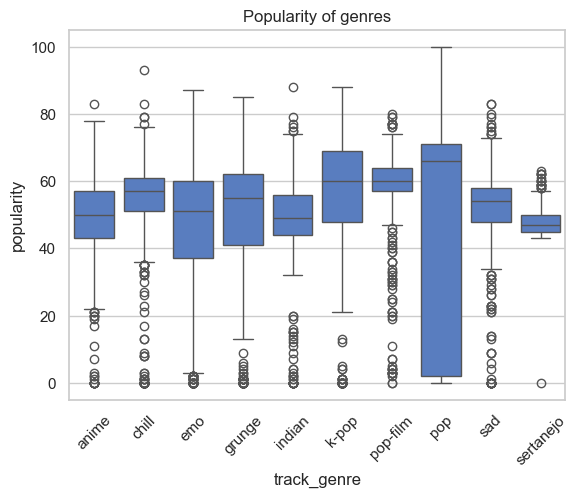

In [10]:
sns.boxplot(
    data=df[df['track_genre'].isin(top_genres)],
    x='track_genre',
    y='popularity'
)

plt.xticks(rotation=45)
plt.title("Popularity of genres")
plt.show()

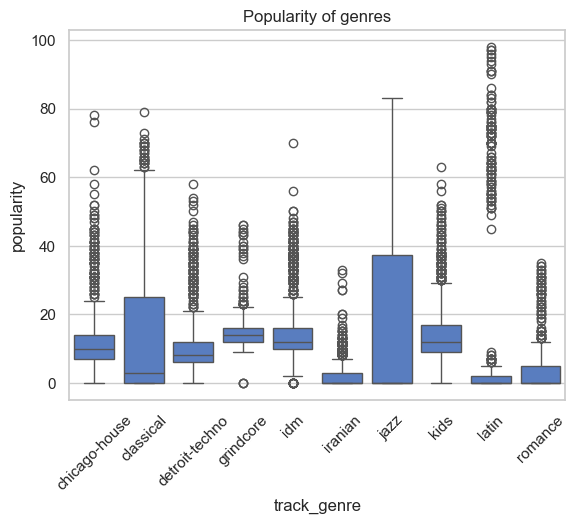

In [11]:
sns.boxplot(
    data=df[df['track_genre'].isin(lowest_popularity_genres)],
    x='track_genre',
    y='popularity'
)

plt.xticks(rotation=45)
plt.title("Popularity of genres")
plt.show()

In [12]:
#Zero popularity values analysis

zero_pop = df[df['popularity'] == 0]

print(zero_pop['track_genre'].value_counts().head(10))
print(zero_pop[['track_name', 'artists', 'track_genre']].sample(10))

track_genre
jazz           681
iranian        656
romance        636
soul           611
latin          588
country        587
rock           525
dance          490
alternative    485
house          403
Name: count, dtype: int64
                                track_name                 artists  \
34698        Inconsciente Colectivo - Live           Mercedes Sosa   
31841                            Baby Girl      Bryce Vine;Jeremih   
47149                Muevan Las Industrias         Los Prisioneros   
67232                              De Cero                   Morat   
101040                   Moments of Static  White Noise for Babies   
34796   I Heard The Bells On Christmas Day          The Civil Wars   
29990                        Last Shuriken            FelMax;SWTCH   
90040                      Run Rudolph Run             Chuck Berry   
78184     Jetzt geht's los - Jahrmarkt-Mix                  Höhner   
93664                              Кумушка          Соня Тимофеева   

 

In [13]:
df_clean = df[df['popularity'] > 0]

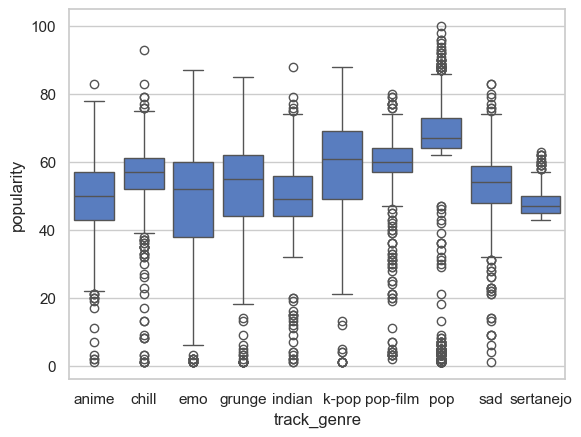

In [14]:
sns.boxplot(
    data = df_clean[df_clean['track_genre'].isin(top_genres)],
    y='popularity',
    x='track_genre'
)
plt.show()

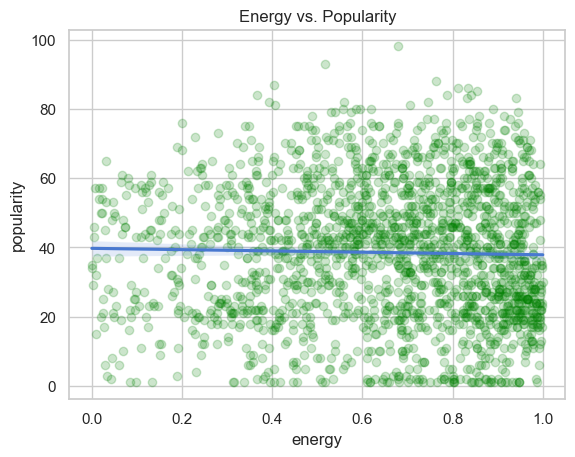

In [15]:
sns.regplot(data=df_clean.sample(2000), x="energy", y="popularity", scatter_kws={"alpha": 0.2, "color":"green"})
plt.title('Energy vs. Popularity')
plt.show()

In [16]:
#As we can see, energy of a song doesn't really correlate that much with its popularity.

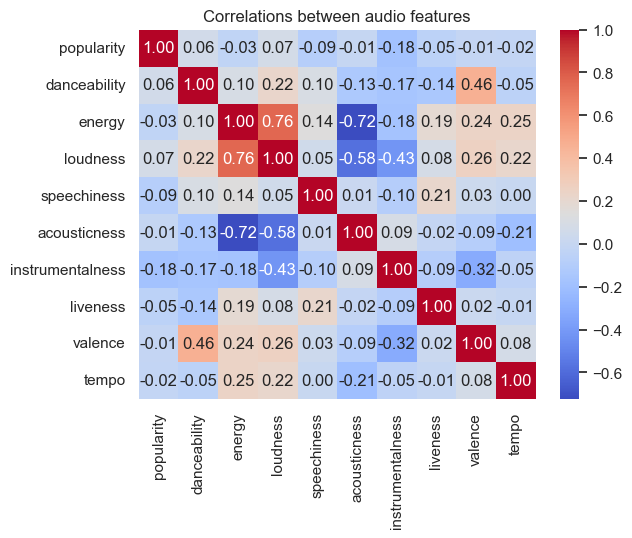

In [17]:
numeric_cols = ['popularity', 'danceability', 'energy', 'loudness',
                'speechiness','acousticness', 'instrumentalness',
                'liveness', 'valence', 'tempo']

corr = df_clean[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlations between audio features")
plt.show()

In [18]:
# Instrumentalness of a song negatively correlates with its popularity (-0.18)

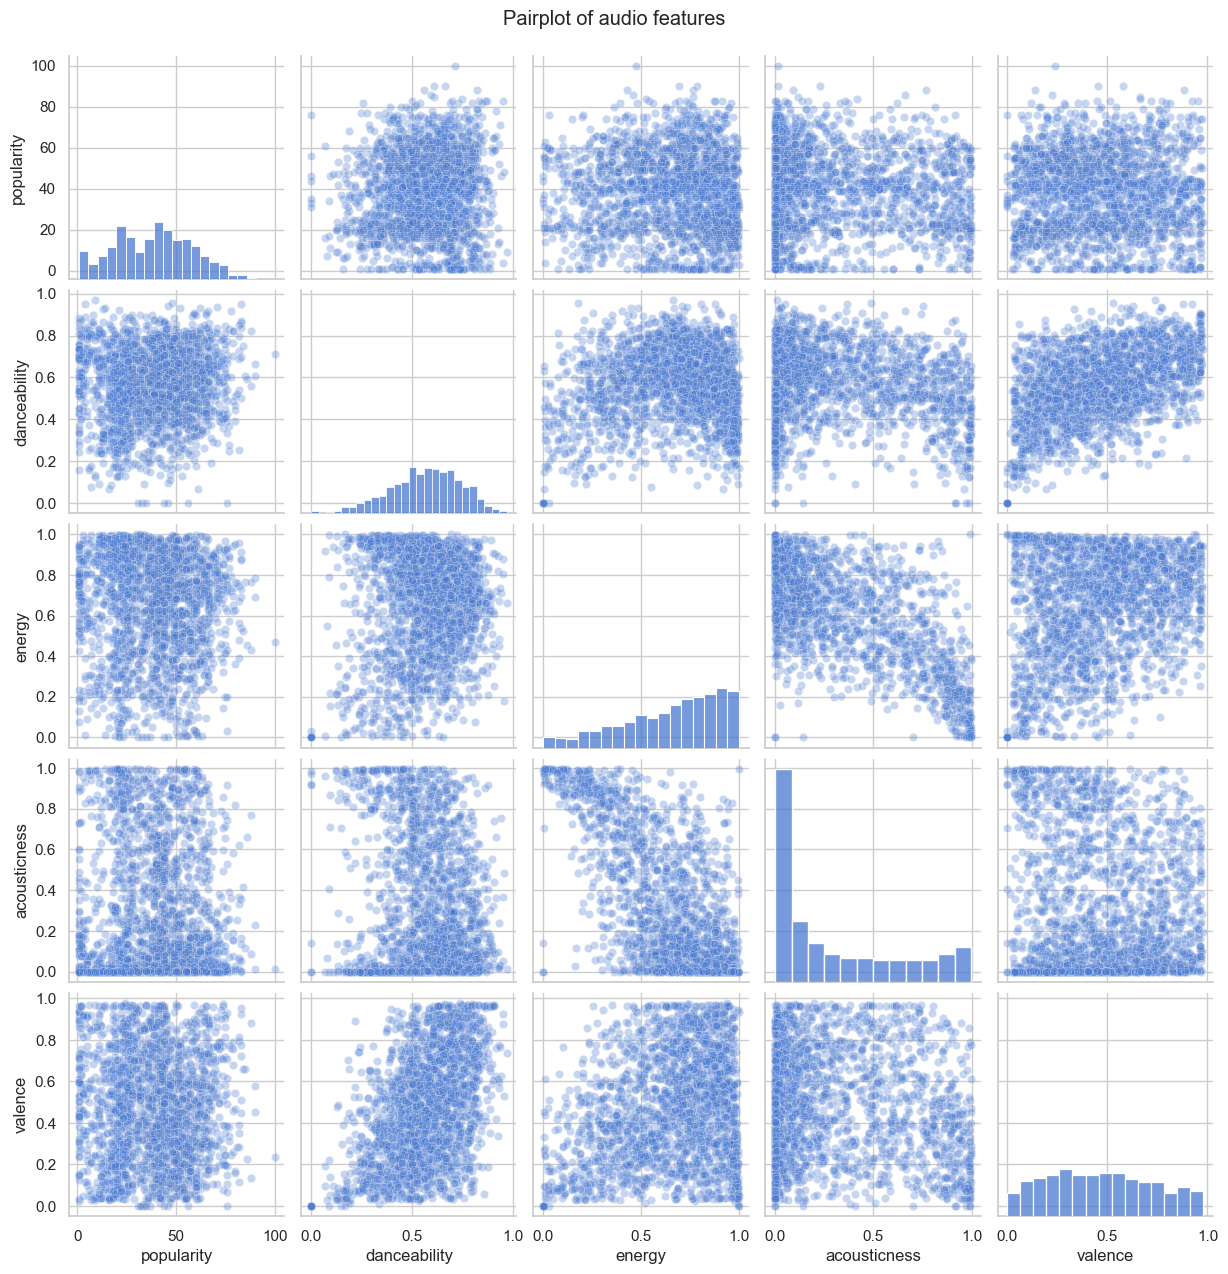

In [19]:
cols = ['popularity', 'danceability', 'energy', 'acousticness', 'valence']

sns.pairplot(
    data=df_clean[cols].sample(2000, random_state=42),
    plot_kws={'alpha': 0.3}
)

plt.suptitle('Pairplot of audio features', y=1.02)
plt.show()